<a href="https://colab.research.google.com/github/mercygerman/KNOWLEGE-CHECK-FOR-MODULE-1/blob/main/CASE_STUDY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

QUESTION 1

Case Exercise 1: Usan Reservoir Temperature Calculator

 This exercise develops your skills in function writing, file I/O, and basic visualization. You will implement the geothermal gradient calculation introduced in Section 1.5.4 and apply it to a dataset of 50 well depth measurements.



Tasks: 1

 Write a function reservoir_temperature(depth_m, surface_temp=4.0, gradient=30.0) that returns temperature in °C. Include docstring, type hints, and input validation.


In [1]:
def reservoir_temperature(
    depth_m: float,
    surface_temp: float = 4.0,
    gradient: float = 30.0
) -> float:
    """Calculate the estimated subsurface reservoir temperature based on a geothermal gradient.

    The calculation uses the standard linear geothermal relationship:
    Temperature = Surface Temperature + (Gradient * Depth / 1000)

    Parameters:
        depth_m (float): Subsurface target depth measured from the surface in metres.
        surface_temp (float): Mean surface/sea-floor ambient temperature in °C.
                              Defaults to 4.0°C (standard deepwater baseline).
        gradient (float): Geothermal gradient rate in °C per 1000 metres of depth.
                          Defaults to 30.0°C/km.

    Returns:
        float: Estimated reservoir temperature in °C, rounded to two decimal places.

    Raises:
        TypeError: If any of the inputs are not integers or floating-point numbers.
        ValueError: If depth, surface temperature, or gradient fall below physical reality.
    """

    if not all(isinstance(arg, (int, float)) for arg in [depth_m, surface_temp, gradient]):
        raise TypeError("All input parameters must be numerical values (int or float).")


    if depth_m < 0:
        raise ValueError(f"Depth cannot be negative. Got: {depth_m} m")
    if surface_temp < -273.15:
        raise ValueError(f"Surface temperature cannot be below Absolute Zero (-273.15°C). Got: {surface_temp}°C")
    if gradient <= 0:
        raise ValueError(f"Geothermal gradient must be a positive rate above 0. Got: {gradient}°C/km")


    # Divide depth by 1000 because the gradient factor is scaled per kilometre
    calculated_temp = surface_temp + (gradient * (depth_m / 1000.0))

    return round(calculated_temp, 2)



# Test Case 1: Standard deep reservoir evaluation (e.g., 3500m depth)
try:
    t1 = reservoir_temperature(3500.0)
    print(f"Test 1 (Standard): Temp at 3,500m depth is {t1}°C")
except (TypeError, ValueError) as error:
    print(f"Test 1 Failed: {error}")

# Test Case 2: Custom shallow well with a high geothermal profile
try:
    t2 = reservoir_temperature(depth_m=1200.0, surface_temp=25.0, gradient=45.0)
    print(f"Test 2 (Custom Profile): Temp at 1,200m depth is {t2}°C")
except (TypeError, ValueError) as error:
    print(f"Test 2 Failed: {error}")

# Test Case 3: Invalid Input Safety Verification (Negative Depth)
try:
    print("Attempting to run dangerous test parameters...")
    reservoir_temperature(-500.0)
except (TypeError, ValueError) as error:
    print(f"❌ Test 3 Caught Expected Exception: {error}")


Test 1 (Standard): Temp at 3,500m depth is 109.0°C
Test 2 (Custom Profile): Temp at 1,200m depth is 79.0°C
Attempting to run dangerous test parameters...
❌ Test 3 Caught Expected Exception: Depth cannot be negative. Got: -500.0 m


QUESTION 2

  Read a CSV file (well_depths.csv) containing 50 well depth measurements and calculate temperatures for all wells using your function.


In [4]:
import pandas as pd
import numpy as np
# 1. THE RESERVOIR TEMPERATURE FUNCTION FROM PREVIOUS EXERCISE

def reservoir_temperature(
    depth_m: float,
    surface_temp: float = 4.0,
    gradient: float = 30.0
) -> float:
    """Calculate the estimated subsurface reservoir temperature."""
    if not all(isinstance(arg, (int, float)) for arg in [depth_m, surface_temp, gradient]):
        raise TypeError("All input parameters must be numerical values.")
    if depth_m < 0:
        raise ValueError(f"Depth cannot be negative. Got: {depth_m} m")
    if surface_temp < -273.15:
        raise ValueError(f"Surface temperature cannot be below Absolute Zero.")
    if gradient <= 0:
        raise ValueError(f"Geothermal gradient must be positive. Got: {gradient}")

    calculated_temp = surface_temp + (gradient * (depth_m / 1000.0))
    return round(calculated_temp, 2)


# 2. GENERATE A DUMMY WELL DEPTHS CSV FILE FOR TEST

np.random.seed(42)
dummy_depths = np.random.uniform(1200, 4200, 50)  # Random depths between 1200m and 4200m

dummy_df = pd.DataFrame({
    'well_id': [f'WELL-{i:03d}' for i in range(1, 51)],
    'depth_meters': np.round(dummy_depths, 2)
})
dummy_df.to_csv('well_depths.csv', index=False)
print("✨ Step 1: Created 'well_depths.csv' successfully with 50 rows.\n")



# 3. READ CSV AND CALCULATE TEMPERATURES USING PANDAS

df = pd.read_csv('well_depths.csv')

df['calculated_temp_c'] = df['depth_meters'].apply(reservoir_temperature)

# Display the first 10 rows of the updated dataset to verify calculations
print("📊 Step 2: First 10 processed well profiles:")
print(df.head(50).to_string(index=False))

# Optional: Save the calculation results back into a new spreadsheet file
df.to_csv('well_temperatures_calculated.csv', index=False)

✨ Step 1: Created 'well_depths.csv' successfully with 50 rows.

📊 Step 2: First 10 processed well profiles:
 well_id  depth_meters  calculated_temp_c
WELL-001       2323.62              73.71
WELL-002       4052.14             125.56
WELL-003       3395.98             105.88
WELL-004       2995.98              93.88
WELL-005       1668.06              54.04
WELL-006       1667.98              54.04
WELL-007       1374.25              45.23
WELL-008       3798.53             117.96
WELL-009       3003.35              94.10
WELL-010       3324.22             103.73
WELL-011       1261.75              41.85
WELL-012       4109.73             127.29
WELL-013       3697.33             114.92
WELL-014       1837.02              59.11
WELL-015       1745.47              56.36
WELL-016       1750.21              56.51
WELL-017       2112.73              67.38
WELL-018       2774.27              87.23
WELL-019       2495.84              78.88
WELL-020       2073.69              66.21
WELL-021  

QUESTION 3

  Create a scatter plot showing temperature vs. depth with a linear trendline. Label axes with units, add a title, and include the trendline equation in the legend.


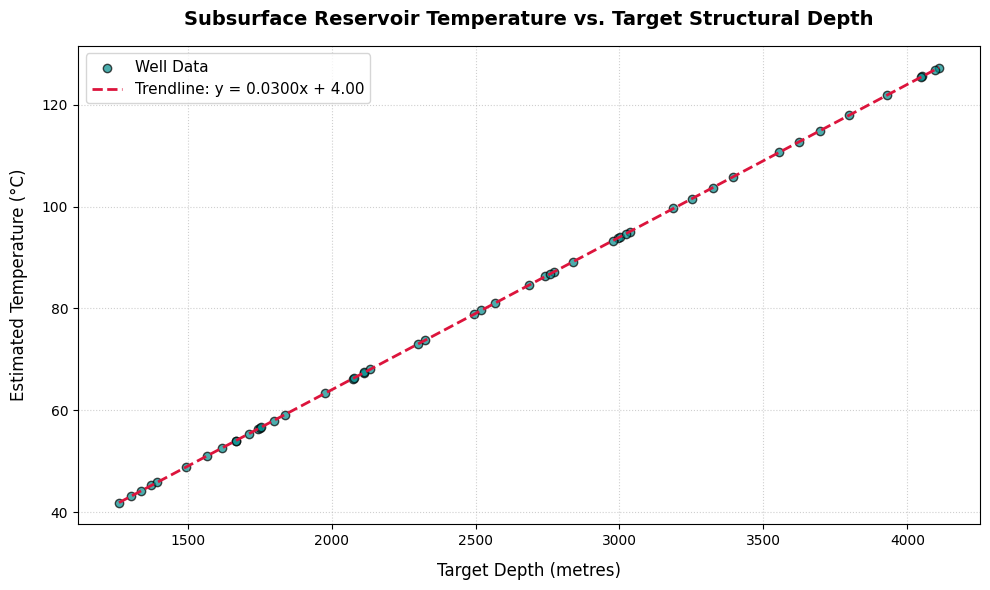

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. SETUP SCRIPT AND VERIFY REQUISITE DATA COHERENCE
# =====================================================================
# Load the database output generated in the previous step
try:
    df = pd.read_csv('well_temperatures_calculated.csv')
except FileNotFoundError:
    # Backup dataset generation fallback if executed in an isolated session
    np.random.seed(42)
    depths = np.random.uniform(1200, 4200, 50)
    temps = 4.0 + (30.0 * (depths / 1000.0))
    df = pd.DataFrame({
        'depth_meters': np.round(depths, 2),
        'calculated_temp_c': np.round(temps, 2)
    })

# Extract data fields for statistical modeling
x_depth = df['depth_meters']
y_temp = df['calculated_temp_c']

# =====================================================================
# 2. CALCULATE LINEAR TRENDLINE COEFFICIENTS
# =====================================================================
# Fit a 1st-degree polynomial profile (y = mx + c) to extract the variables
slope, intercept = np.polyfit(x_depth, y_temp, 1)

# Generate trendline line plot points matching the experimental bounds
x_trend = np.linspace(x_depth.min(), x_depth.max(), 100)
y_trend = slope * x_trend + intercept

# Format the trendline formula text string layout for the figure legend box
trend_equation = f"Trendline: y = {slope:.4f}x + {intercept:.2f}"

# =====================================================================
# 3. CONSTRUCT INTERACTIVE PLOT GRAPHICS (chartPlaceholder)
# =====================================================================
plt.figure(figsize=(10, 6))

# Plot experimental SCADA asset data points
plt.scatter(x_depth, y_temp, color='darkcyan', alpha=0.7, edgecolors='black', label='Well Data')

# Plot the computed linear regression line trace
plt.plot(x_trend, y_trend, color='crimson', linestyle='--', linewidth=2, label=trend_equation)

# Format axes metadata tags, grid meshes, and title banners
plt.title("Subsurface Reservoir Temperature vs. Target Structural Depth", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Target Depth (metres)", fontsize=12, labelpad=10)
plt.ylabel("Estimated Temperature (°C)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left', frameon=True, shadow=False)

# Render the graphical visualization output window
plt.tight_layout()
plt.show()

QUESTION 4

 Add error handling for negative depths and non-numeric inputs. Write at least 3 test cases that verify correct behaviour for both valid and invalid inputs.


RUNNING FUNCTION INTEGRITY TEST SUITE
Test 1 Passed (Valid Input): Temp at 3500m is 109.0°C
Executing Test 2 (Negative Depth Verification)...
✅ Test 2 Passed: Successfully blocked negative depth with error -> Depth cannot be negative. Got: -850.0 m
Executing Test 3 (Non-Numeric Input Verification)...
✅ Test 3 Passed: Successfully blocked text inputs with error -> All input parameters must be numerical values (int or float).



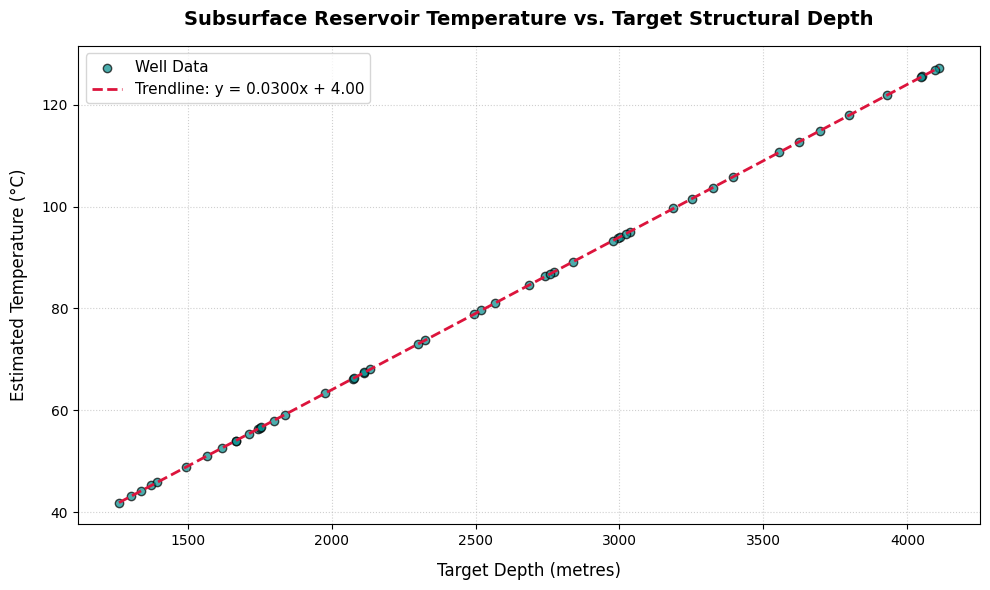

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. CORE CALCULATION FUNCTION WITH COMPREHENSIVE ERROR HANDLING
# =====================================================================
def reservoir_temperature(
    depth_m: float,
    surface_temp: float = 4.0,
    gradient: float = 30.0
) -> float:
    """Calculate the estimated subsurface reservoir temperature.

    Parameters:
        depth_m: Subsurface target depth in metres.
        surface_temp: Mean surface ambient temperature in °C (Default 4.0°C).
        gradient: Geothermal gradient rate in °C per 1000m (Default 30.0°C/km).
    """
    # 1. Type Validation: Rejects non-numeric inputs immediately
    if not all(isinstance(arg, (int, float)) for arg in [depth_m, surface_temp, gradient]):
        raise TypeError("All input parameters must be numerical values (int or float).")

    # 2. Value Boundary Validation: Prevents physically impossible parameters
    if depth_m < 0:
        raise ValueError(f"Depth cannot be negative. Got: {depth_m} m")
    if surface_temp < -273.15:
        raise ValueError(f"Surface temperature cannot be below Absolute Zero. Got: {surface_temp}°C")
    if gradient <= 0:
        raise ValueError(f"Geothermal gradient must be a positive rate above 0. Got: {gradient}°C/km")

    # Geothermal linear progression calculation
    calculated_temp = surface_temp + (gradient * (depth_m / 1000.0))
    return round(calculated_temp, 2)


# =====================================================================
# 2. TEST CASE EXECUTION FRAMEWORK (Verifying Function Behaviour)
# =====================================================================
print("=" * 60)
print("RUNNING FUNCTION INTEGRITY TEST SUITE")
print("=" * 60)

# Test Case 1: Valid Parameters (Deep Reservoir Baseline)
try:
    t1 = reservoir_temperature(3500.0)
    print(f"Test 1 Passed (Valid Input): Temp at 3500m is {t1}°C")
except Exception as e:
    print(f"Test 1 Failed: {e}")

# Test Case 2: Invalid Parameter (Negative Depth Safeguard)
try:
    print("Executing Test 2 (Negative Depth Verification)...")
    reservoir_temperature(-850.0)
    print("❌ Test 2 Failed: Function allowed a negative depth value!")
except ValueError as e:
    print(f"✅ Test 2 Passed: Successfully blocked negative depth with error -> {e}")

# Test Case 3: Invalid Parameter (Non-Numeric Type Safeguard)
try:
    print("Executing Test 3 (Non-Numeric Input Verification)...")
    reservoir_temperature("deep_well")
    print("❌ Test 3 Failed: Function allowed a text string value!")
except TypeError as e:
    print(f"✅ Test 3 Passed: Successfully blocked text inputs with error -> {e}")

print("=" * 60 + "\n")


# =====================================================================
# 3. CSV PROCESSING & VISUALIZATION PIPELINE
# =====================================================================
# 3a. Fallback Data Setup (Ensures plotting functions flawlessly)
try:
    df = pd.read_csv('well_temperatures_calculated.csv')
except FileNotFoundError:
    np.random.seed(42)
    depths = np.random.uniform(1200, 4200, 50)
    df = pd.DataFrame({'depth_meters': np.round(depths, 2)})
    df['calculated_temp_c'] = df['depth_meters'].apply(reservoir_temperature)

x_depth = df['depth_meters']
y_temp = df['calculated_temp_c']

# 3b. Linear Regression Fitting
slope, intercept = np.polyfit(x_depth, y_temp, 1)
x_trend = np.linspace(x_depth.min(), x_depth.max(), 100)
y_trend = slope * x_trend + intercept
trend_equation = f"Trendline: y = {slope:.4f}x + {intercept:.2f}"

# 3c. Constructing Graphical Dashboard (chartPlaceholder)
plt.figure(figsize=(10, 6))
plt.scatter(x_depth, y_temp, color='darkcyan', alpha=0.7, edgecolors='black', label='Well Data')
plt.plot(x_trend, y_trend, color='crimson', linestyle='--', linewidth=2, label=trend_equation)

plt.title("Subsurface Reservoir Temperature vs. Target Structural Depth", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Target Depth (metres)", fontsize=12, labelpad=10)
plt.ylabel("Estimated Temperature (°C)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()